In [1]:
import geopandas as gpd
from shapely import Polygon
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd

In [2]:
brno_b_point = r"data\brno_build_points.geojson"
grid = r"data\brno_grid.shp" # 1km*1km
brno_outline = r"data\Brno_outline.shp"
brno_floor = r"data\brno_buildings.geojson"
b_outline = gpd.read_file(brno_outline)
b_point = gpd.read_file(brno_b_point )
b_grid = gpd.read_file(grid)
b_floor = gpd.read_file(brno_floor)

In [3]:
floors = b_floor.loc[:,'np1_1f':'np28_1f1']

In [4]:
def row_to_dict(row):
    result = {}
    for col in row.index:
        if col.endswith('_rel'):
            continue

        label = row[col]
        if (pd.isna(label)) or (label.strip() == ''):
            continue
        
        rel_col = f'{col}_rel'
        value = row[rel_col] if rel_col in row.index and pd.notna(row[rel_col]) else 100

        result[label] = result.get(label, 0) + int(float(value))

    return result

dict_series = floors.apply(row_to_dict, axis=1)

In [48]:
df = pd.DataFrame.from_records(dict_series, index=dict_series.index).fillna(0)
df['Non_residential'] = df.drop(columns=['bydlení']).sum(axis=1)
b_floor[['Non_residential','bydlení']] = df[['Non_residential','bydlení']]

In [6]:
# from 2:00 to 23:00
resident_prop = np.array([1.0,1.0,1.0,1.0,0.98,0.95,0.90,0.60,0.3,0.25,0.25,0.25,0.25,0.30,0.35,0.40,0.50,0.60,0.70,0.75,0.85,0.90])

In [20]:
grid_clip = b_grid[b_grid.intersects(b_outline.geometry[0])]

In [49]:
b_floor['area_floor_origin'] = b_floor.geometry.area
b_floor = b_floor.to_crs('EPSG:5514')
overlay = gpd.overlay(grid_clip,b_floor,'intersection')
overlay['overlay_area']=overlay.geometry.area
overlay.sort_values('overlay_area',inplace=True)
overlay.drop_duplicates(subset='objectid', keep='last', inplace= True)
overlay['area_non_resident'] = overlay['area_floor_origin']*overlay['Non_residential']/100

In [50]:
grid_non_resident = grid_clip.sjoin(overlay,'left','contains').groupby(level=0)['area_non_resident'].sum()

In [ ]:
non_prop = np.array(grid_non_resident/grid_non_resident.sum()) # Non-residential area proportions of each grid cell

In [56]:

grid_pop = grid_clip.sjoin(b_point,'left','contains').groupby(level=0)['budobyev'].sum()
grid_clip['resident_num'] = grid_pop
resident = grid_clip['resident_num'].to_numpy()
resident_dynamic = np.tile(resident_prop,(289,1)) * resident[:,np.newaxis]

In [60]:
non_re_dynamic = abs(np.sum(resident_dynamic,axis=0) - 359194) * non_prop[:,np.newaxis]

In [62]:
grid_dynamic = resident_dynamic+non_re_dynamic

In [63]:
for i in range(22):
    key = str(i+2)
    grid_clip[key] = grid_dynamic[:,i]

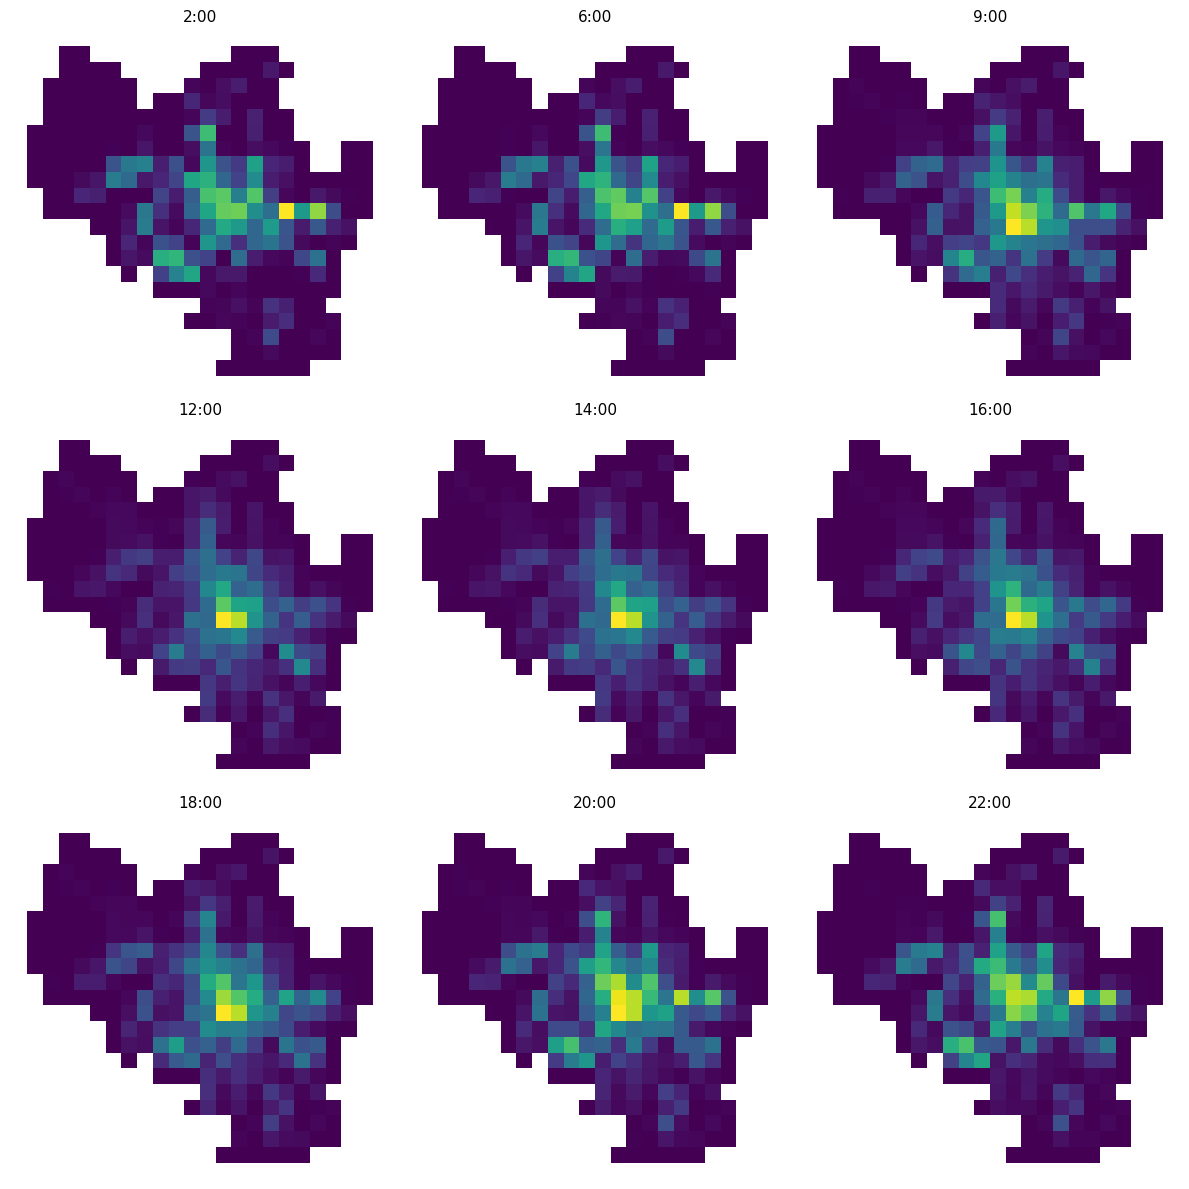

In [67]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12))

cols = ['2','6', '9', '12', '14', '16','18', '20','22']
titles = ['2:00','6:00', '9:00', '12:00', '14:00', '16:00','18:00', '20:00','22:00']
vmin = min(grid_clip[c].min() for c in cols)
vmax = max(grid_clip[c].max() for c in cols)

cmap = "viridis"
for a, c, t in zip(ax.flat, cols, titles):
    grid_clip.plot(
        column=c,
        ax=a,
    )
    a.set_title(t, fontsize=11)  # label
    a.set_axis_off()             # hide axis outline/ticks
    

plt.tight_layout()
plt.show()